In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("../data/processed/spillover_risk_index.csv")

df

,Temperature,Humidity,NDVI,Forest_Loss,Risk_Index,Risk_Level
0,24.397077,65.227231,0.214758,0.453264,0.513316,Moderate Risk


In [3]:
synthetic_data = pd.DataFrame({
    "Temperature": np.random.normal(df["Temperature"][0], 2, 200),
    "Humidity": np.random.normal(df["Humidity"][0], 5, 200),
    "NDVI": np.random.normal(df["NDVI"][0], 0.1, 200),
    "Forest_Loss": np.random.normal(df["Forest_Loss"][0], 0.2, 200)
})

synthetic_data.head()

,Temperature,Humidity,NDVI,Forest_Loss
0,23.079827,65.413364,0.217517,0.654943
1,22.444745,63.622548,0.387466,0.474830
2,21.671732,70.024828,0.223974,0.705296
3,22.231711,66.103610,0.073887,0.551929
4,21.400649,64.859200,0.188662,0.612420


In [4]:
synthetic_data["Outbreak_Risk"] = (
    (
        (synthetic_data["Temperature"] > 25) &
        (synthetic_data["Humidity"] > 60) &
        (synthetic_data["NDVI"] < 0.3)
    )
).astype(int)

synthetic_data.head()

,Temperature,Humidity,NDVI,Forest_Loss,Outbreak_Risk
0,23.079827,65.413364,0.217517,0.654943,0
1,22.444745,63.622548,0.387466,0.474830,0
2,21.671732,70.024828,0.223974,0.705296,0
3,22.231711,66.103610,0.073887,0.551929,0
4,21.400649,64.859200,0.188662,0.612420,0


In [5]:
X = synthetic_data[
    ["Temperature", "Humidity", "NDVI", "Forest_Loss"]
]

y = synthetic_data["Outbreak_Risk"]

print(X.head())
print(y.head())

   Temperature   Humidity      NDVI  Forest_Loss
0    23.079827  65.413364  0.217517     0.654943
1    22.444745  63.622548  0.387466     0.474830
2    21.671732  70.024828  0.223974     0.705296
3    22.231711  66.103610  0.073887     0.551929
4    21.400649  64.859200  0.188662     0.612420
0    0
1    0
2    0
3    0
4    0
Name: Outbreak_Risk, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
predictions = model.predict(X_test)

print(predictions[:10])

[1 1 1 1 0 0 0 0 0 1]


In [9]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.93      1.00      0.96        13

    accuracy                           0.97        40
   macro avg       0.96      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



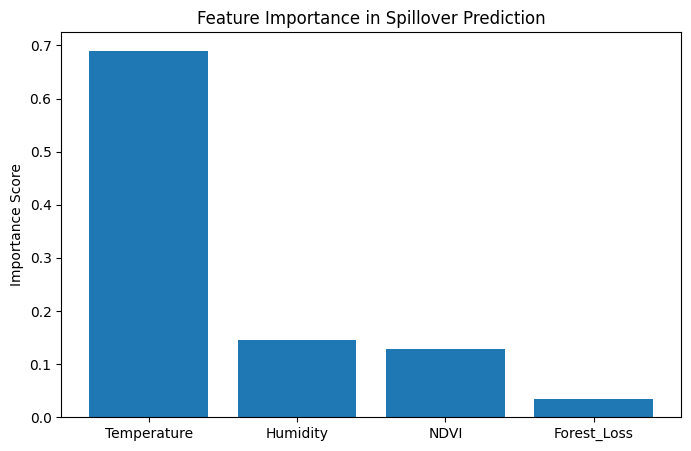

In [10]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = [
    "Temperature",
    "Humidity",
    "NDVI",
    "Forest_Loss"
]

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.ylabel("Importance Score")

plt.title("Feature Importance in Spillover Prediction")

plt.show()

In [11]:
new_data = pd.DataFrame({
    "Temperature": [28],
    "Humidity": [75],
    "NDVI": [0.2],
    "Forest_Loss": [1.5]
})

prediction = model.predict(new_data)

probability = model.predict_proba(new_data)

print("Prediction:", prediction[0])

print("Outbreak Probability:", probability[0][1])

Prediction: 1
Outbreak Probability: 0.95
